In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as pl
import mdtraj as md
import matplotlib as mpl
#from nglview.player import TrajectoryPlayer
import os
from Bio import pairwise2
import pandas
import itertools
from matplotlib import rc
from matplotlib import rcParams


In [2]:
# You can edit these at some point if you want to change the formatting of your figures
font = {'family' : 'Arial',
        'weight' : 'bold',
        'size'   : 20}
COLOR = 'black'
rcParams['text.color'] = 'black'
rcParams['axes.labelcolor'] = COLOR
rcParams['xtick.color'] = COLOR
rcParams['ytick.color'] = COLOR

rc('font', **font)

In [45]:
# These were the inputs used for VMD. Keep them here for posterity/ease of finding
cd1_resids = '12 14 16 26 28 30 38 40 47 58 63 66 69 70 73 76 77 80 81 88 90 96 98 100 114 116 118 123 124 131 140 141 144 148 151 153 154 157 158 161 162 165 166 169 173'
cd1_resname = 'CQSTGAHWVFWLIFYSFDVLLLVAFVFILWWVALDWTTVLLTCFL'
ufa_resids = '10 12 14 28 30 32 38 62 65 66 69 73 77 81 84 85 88 95 97 99 111 113 115 121 123 125 128 130 132 135 137 139 140 142 143 146 147 153 154 156 157 160 161 164 168 172'
ufa_resname = 'LYFMGLEYEQALIILVLVWCVLVVCLVCGVSLIMIILFILLRCNVG'
rae1_resids = "5 7 9 24 26 31 33 34 54 57 60 61 65 68 72 76 92 94 96 110 112 114 118 120 122 136 139 143 149 153 156 169 164 167"
rae1_resname = ''

# SASA Files Must be Generated With "calc_sasa.tcl"
- This one calculating file contains the selections in the cell above
- Can cycle through to select for each specific molecule, and load in each specific dataset
- Need to load PDBs and DCDs into VMD, then "source" the script

In [32]:
# The temperatures can either be 27 or 37
temp=37

if temp ==27:
    cd1_sasa1 = pandas.read_csv('datfiles/cdd271.dat',header=None)
    cd1_sasa2 = pandas.read_csv('datfiles/cdd272.dat',header=None)
    cd1_sasa3 = pandas.read_csv('datfiles/cdd273.dat',header=None)
    ufa_sasa1 = pandas.read_csv('datfiles/ufa271.dat',header=None)
    ufa_sasa2 = pandas.read_csv('datfiles/ufa272.dat',header=None)
    ufa_sasa3 = pandas.read_csv('datfiles/ufa273.dat',header=None)
    rae_sasa1 = pandas.read_csv('datfiles/rae271.dat',header=None)
    rae_sasa2 = pandas.read_csv('datfiles/rae272.dat',header=None)
    rae_sasa3 = pandas.read_csv('datfiles/rae273.dat',header=None)

if temp==37:
    cd1_sasa1 = pandas.read_csv('datfiles/cdd371.dat',header=None)
    cd1_sasa2 = pandas.read_csv('datfiles/cdd372.dat',header=None)
    cd1_sasa3 = pandas.read_csv('datfiles/cdd373.dat',header=None)
    ufa_sasa1 = pandas.read_csv('datfiles/ufa371.dat',header=None)
    ufa_sasa2 = pandas.read_csv('datfiles/ufa372.dat',header=None)
    ufa_sasa3 = pandas.read_csv('datfiles/ufa373.dat',header=None)
    rae_sasa1 = pandas.read_csv('datfiles/rae371.dat',header=None)
    rae_sasa2 = pandas.read_csv('datfiles/rae372.dat',header=None)
    rae_sasa3 = pandas.read_csv('datfiles/rae373.dat',header=None)

# The snippet of code for finding where the max SASA occurs

In [4]:
sasa = ufa_sasa3
i = sasa.idxmax().values[0]
print(sasa.max())
print('Frame: '+str(i%200)+', Dyn: '+str(np.ceil(i/200.0)))

0    1289.253052
dtype: float64
Frame: 93, Dyn: 8.0


# Plotting the Primary Data: Comparisons Across Simulations

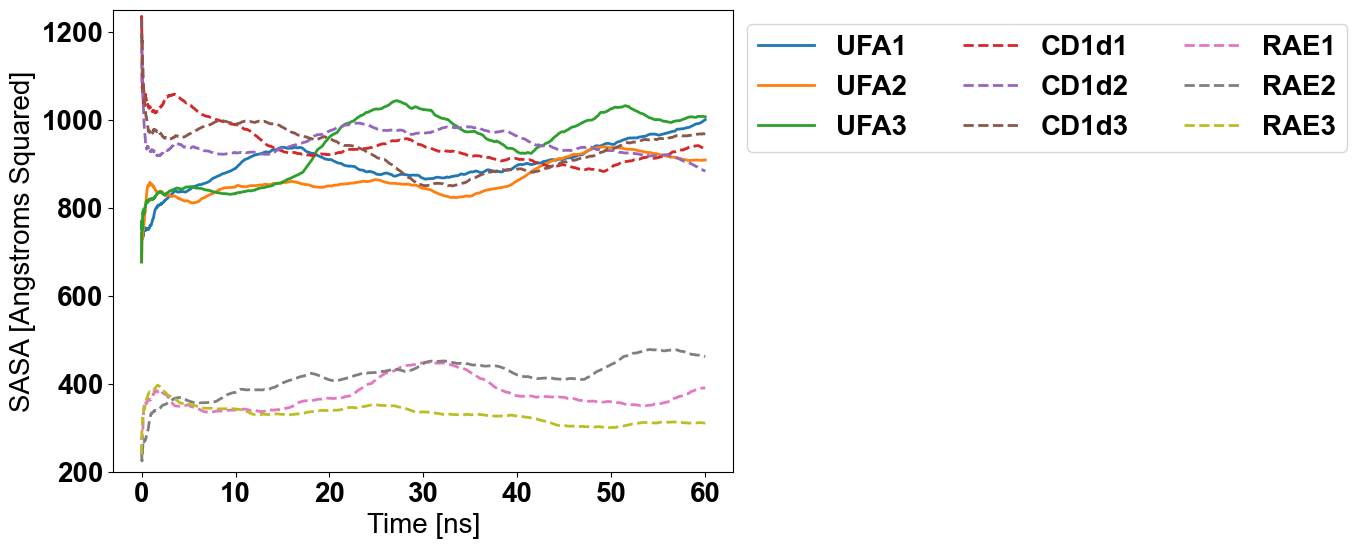

In [37]:
fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(8,6))

# Running average of trajectories
# Alter the window size of your running average
win=1000
a = 1
for sasa in [ufa_sasa1.values,ufa_sasa2.values,ufa_sasa3.values]:
    zz1=np.zeros(len(sasa))
    for i in range(len(sasa)):
        if i < win:
            zz1[i]=sum(sasa[:(i+1)])/(i+1)
        else:
            zz1[i]=sum(sasa[(i-win):(i+1)])/win
    xaxis = np.arange(0,60,60.0/len(zz1))
    pl.plot(xaxis,zz1,linewidth=2)
    
a=1
for sasa in [cd1_sasa1.values,cd1_sasa2.values,cd1_sasa3.values]:
    zz1=np.zeros(len(sasa))
    for i in range(len(sasa)):
        if i < win:
            zz1[i]=sum(sasa[:(i+1)])/(i+1)
        else:
            zz1[i]=sum(sasa[(i-win):(i+1)])/win
    xaxis = np.arange(0,60,60.0/len(zz1))
    pl.plot(xaxis,zz1,linewidth=2,linestyle='dashed')

a=1
for sasa in [rae_sasa1.values,rae_sasa2.values,rae_sasa3.values]:
    zz1=np.zeros(len(sasa))
    for i in range(len(sasa)):
        if i < win:
            zz1[i]=sum(sasa[:(i+1)])/(i+1)
        else:
            zz1[i]=sum(sasa[(i-win):(i+1)])/win
    xaxis = np.arange(0,60,60.0/len(zz1))
    pl.plot(xaxis,zz1,linewidth=2,linestyle='dashed')

pl.ylim([200,1250])
pl.xlabel('Time [ns]')
pl.ylabel('SASA [Angstroms Squared]')
pl.legend(['UFA1','UFA2','UFA3','CD1d1','CD1d2','CD1d3','RAE1','RAE2','RAE3'],ncol=3,bbox_to_anchor=(1,1),loc='upper left')
#pl.savefig('sasa_avg_'+str(temp)+'.pdf',format='pdf')

# Recreate Supplemental Figure S7

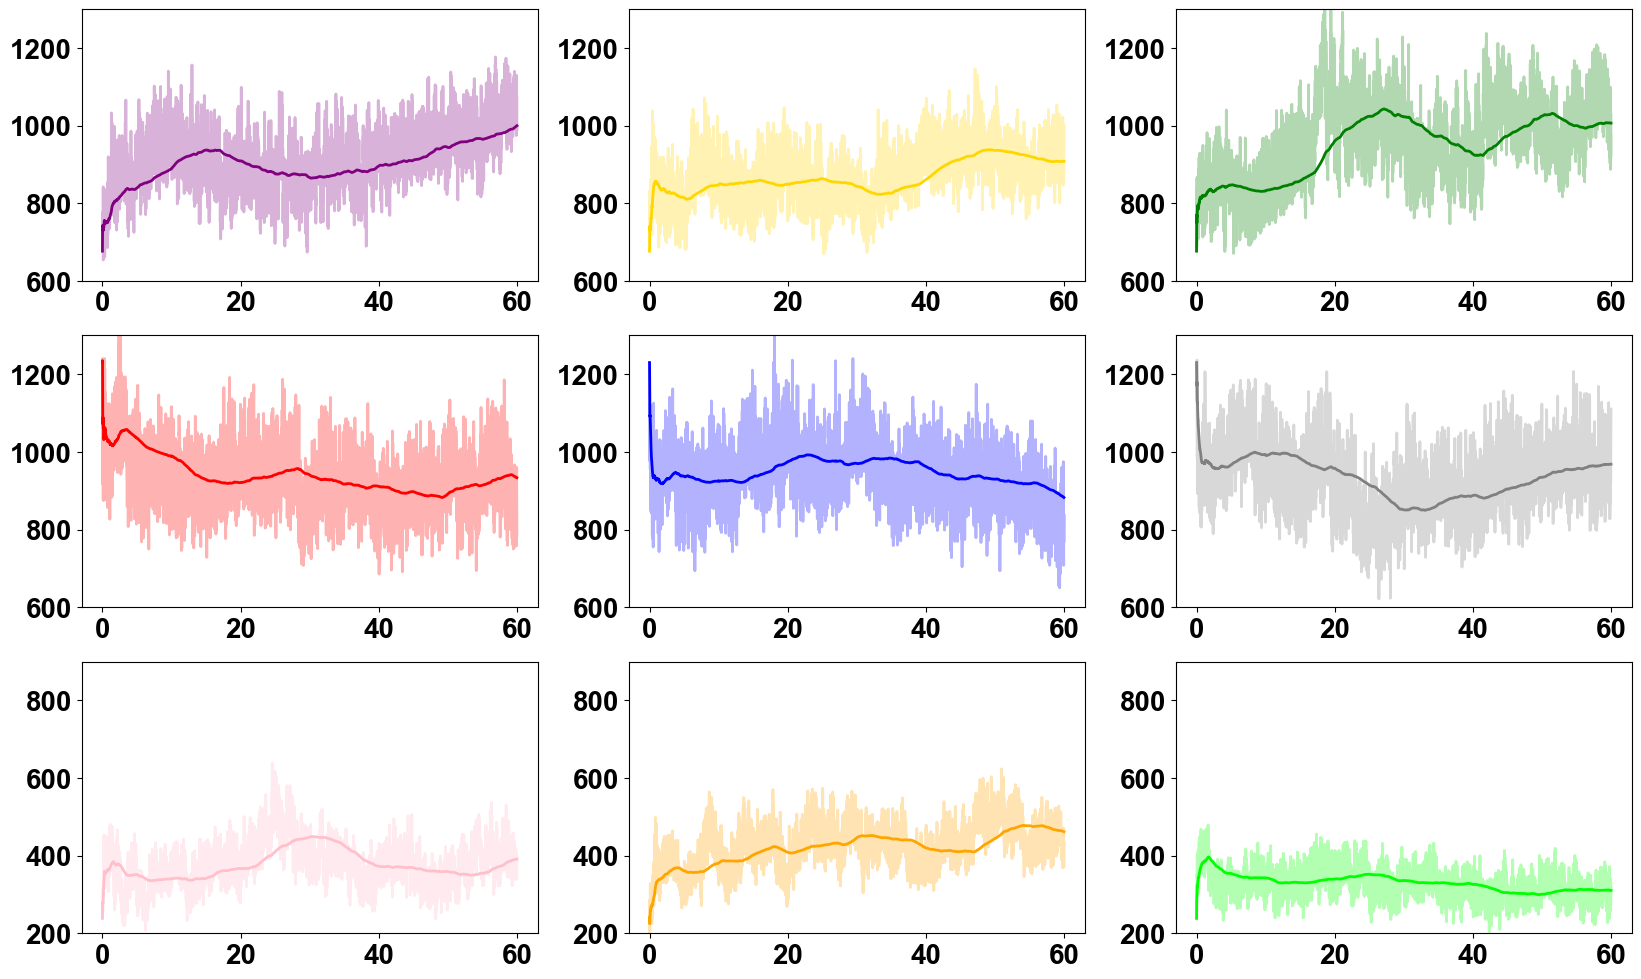

In [41]:
fig, ax = pl.subplots(3, 3,squeeze=False,figsize=(20,12))

win=1000

acolors = ['Purple','Gold','Green']
a=0
for sasa in [ufa_sasa1.values,ufa_sasa2.values,ufa_sasa3.values]:
    zz1=np.zeros(len(sasa))
    for i in range(len(sasa)):
        if i < win:
            zz1[i]=sum(sasa[:(i+1)])/(i+1)
        else:
            zz1[i]=sum(sasa[(i-win):(i+1)])/win
    xaxis = np.arange(0,60,60.0/len(zz1))
    ax[0,a].plot(xaxis,sasa,linewidth=2,alpha=0.3,color=acolors[a])
    ax[0,a].plot(xaxis,zz1,linewidth=2,color=acolors[a])
    ax[0,a].set_ylim([600,1300])
    a+=1

a=0
acolors = ['Red','Blue','Grey']
for sasa in [cd1_sasa1.values,cd1_sasa2.values,cd1_sasa3.values]:
    zz1=np.zeros(len(sasa))
    for i in range(len(sasa)):
        if i < win:
            zz1[i]=sum(sasa[:(i+1)])/(i+1)
        else:
            zz1[i]=sum(sasa[(i-win):(i+1)])/win
    xaxis = np.arange(0,60,60.0/len(zz1))
    ax[1,a].plot(xaxis,sasa,linewidth=2,alpha=0.3,color=acolors[a])
    ax[1,a].plot(xaxis,zz1,linewidth=2,color=acolors[a])
    ax[1,a].set_ylim([600,1300])
    a+=1

a=0
acolors = ['Pink','Orange','Lime']
for sasa in [rae_sasa1.values,rae_sasa2.values,rae_sasa3.values]:
    zz1=np.zeros(len(sasa))
    for i in range(len(sasa)):
        if i < win:
            zz1[i]=sum(sasa[:(i+1)])/(i+1)
        else:
            zz1[i]=sum(sasa[(i-win):(i+1)])/win
    xaxis = np.arange(0,60,60.0/len(zz1))
    ax[2,a].plot(xaxis,sasa,linewidth=2,alpha=0.3,color=acolors[a])
    ax[2,a].plot(xaxis,zz1,linewidth=2,color=acolors[a])
    ax[2,a].set_ylim([200,900])
    a+=1


# Potential "Bonus" Calculations. Not clear these are needed for all analysis
- For now, we'll need to use "dummy" PDB and DCD, since they are too large to include on the GitHub
- Edit as needed for your analysis

In [43]:
topfile = '../step3_input.pdb'
struct = md.load_pdb(topfile)
table,bonds = struct.topology.to_dataframe()
# Use this to print out what we're actually looking at
struct.topology

<mdtraj.Topology with 4 chains, 28071 residues, 88651 atoms, 61037 bonds at 0x71373bb149d0>

# Select the proper residues for your molecule of interest. Here CD1d for us

In [46]:
mdsel_full = struct.topology.select("chainid == 0 and resid 1 to 180 and name CA ")
mdsel = struct.topology.select("chainid == 0 and sidechain and not name H and residue "+cd1_resids)

# Calculation of the "pocket dists" were wildly slow
- So, if you want to calculate distances, you should do so with only very specific amino acids

In [49]:
# This is how I deal with memory issues
# I had explicitly defined the names of the trajectory files
# in the "trajfile" instance. In this system, I can probably just 
# do for i in np.arange(30) load dyn+str(i)
frames=200
first_frame = md.load_frame(topfile,0)
rmsdpre = []
rmsdFullpre = []
max_dyn = 2
#pocket_pairs = list(itertools.product(mdsel, mdsel))
sasa_pre=[]
for dyn in np.arange(max_dyn):
    chunk=md.load('../dyn'+str(dyn+1)+'.dcd',top=topfile)
    rmsdpre.append(md.rmsd(chunk, first_frame,atom_indices=mdsel))
    rmsdFullpre.append(md.rmsd(chunk, first_frame,atom_indices=mdsel_full))
    
    #pocket_dists = md.compute_distances(chunk, atom_pairs=pocket_pairs, periodic=False)
    
#cryst_dists = md.compute_distances(first_frame, atom_pairs=pocket_pairs, periodic=False)
rmsd=np.reshape(rmsdpre,(max_dyn)*frames)
rmsdFull=np.reshape(rmsdFullpre,(max_dyn)*frames)

# Plot RMSDs

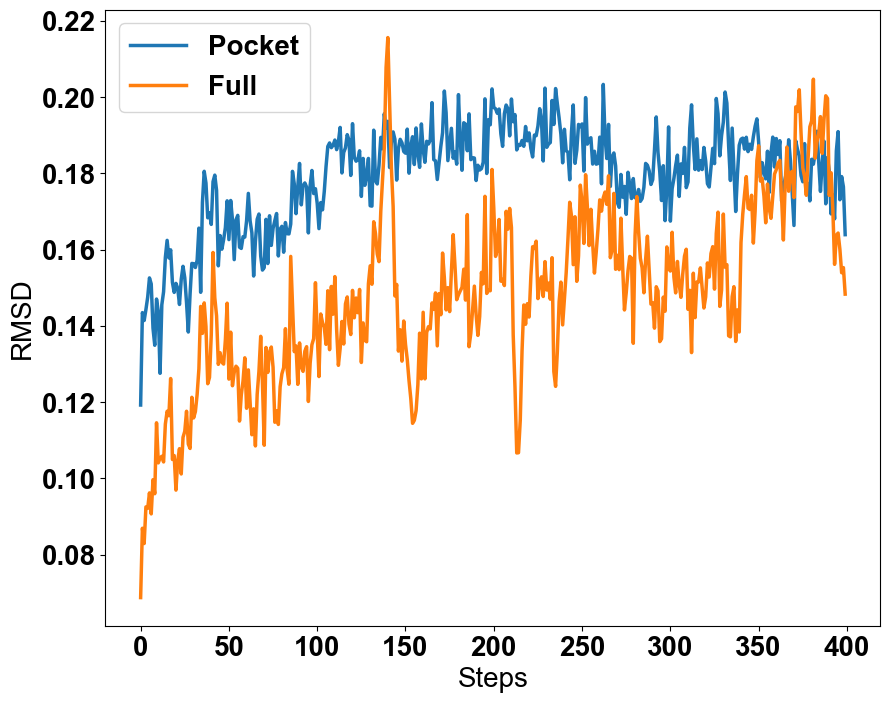

In [50]:
fig, ax = pl.subplots(1, 1,squeeze=False,figsize=(10,8))
pl.plot(rmsd,linewidth=2.5)
pl.plot(rmsdFull,linewidth=2.5)
pl.xlabel('Steps')
pl.ylabel('RMSD')
pl.legend(['Pocket','Full'])

# Will need to more carefully alter the code to deal with inter-residue distances
- Things were way too slow how I used to do it